## 1.加载Task4数据

In [8]:
import pandas as pd
import numpy as np
import scipy.sparse as sp
import json

# 1. 加载特征矩阵 (稀疏矩阵格式)
X_train = sp.load_npz('../task4_feature_engineering/output/X_train.npz')
X_val = sp.load_npz('../task4_feature_engineering/output/X_val.npz')
X_test = sp.load_npz('../task4_feature_engineering/output/X_test.npz')

# 2. 加载标签数据 (仅提取 'label_id' 这一列的整数)
y_train = pd.read_csv('../task4_feature_engineering/output/y_train.csv')['label_id'].values
y_val = pd.read_csv('../task4_feature_engineering/output/y_val.csv')['label_id'].values
y_test = pd.read_csv('../task4_feature_engineering/output/y_test.csv')['label_id'].values

# 3. 加载元数据 (特征名、类别映射、类别权重)
feature_names_df = pd.read_csv('../task4_feature_engineering/output/feature_names.csv')
feature_names = feature_names_df.iloc[:, 0].tolist() 

with open('../task4_feature_engineering/output/label_mapping.json', 'r') as f:
    label_mapping_data = json.load(f)
label_mapping = label_mapping_data['labels']
# 按 0, 1, 2, 3, 4 的顺序恢复类别名称列表
target_names = [k for k, v in sorted(label_mapping.items(), key=lambda item: item[1])]

with open('../task4_feature_engineering/output/class_weights.json', 'r') as f:
    class_weights_data = json.load(f)
class_weights_dict = class_weights_data['class_weights']

# 生成训练集的样本权重
sample_weights = np.array([class_weights_dict[target_names[y]] for y in y_train])

print(f"训练集特征维度: {X_train.shape}, 测试集特征维度: {X_test.shape}")
print(f"训练集标签维度: {y_train.shape}")
print(f"前5个标签验证: {y_train[:5]}")

训练集特征维度: (810, 758), 测试集特征维度: (253, 758)
训练集标签维度: (810,)
前5个标签验证: [0 3 1 0 1]


## 2.lightgbm训练与accuracy\auc\混淆矩阵\热力图

开始静默训练 LightGBM 模型...

LightGBM 训练完成！最终评估结果如下：
准确率 (Accuracy)       : 0.6285
多分类 AUC (Macro-OVR)  : 0.9033

详细分类报告 (Classification Report):
                 precision    recall  f1-score   support

       Everyone       0.58      0.69      0.63        36
   Everyone 10+       0.50      0.75      0.60        28
           Teen       0.59      0.57      0.58        68
     Mature 17+       0.76      0.53      0.63        73
Adults only 18+       0.69      0.73      0.71        48

       accuracy                           0.63       253
      macro avg       0.62      0.66      0.63       253
   weighted avg       0.65      0.63      0.63       253



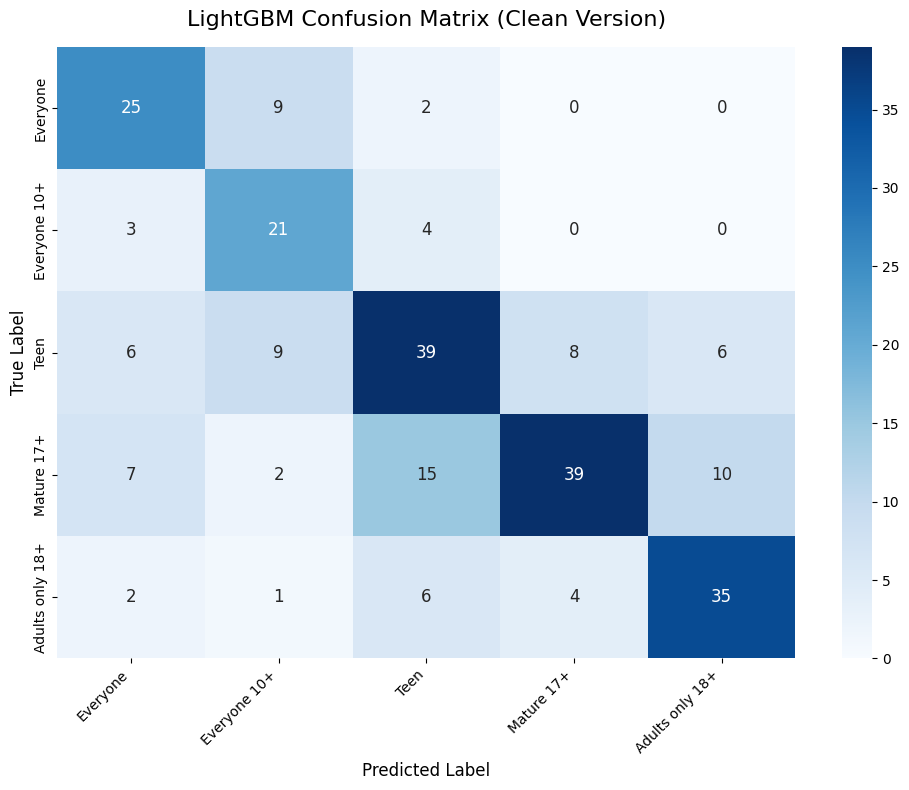

In [9]:
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import numpy as np

# 1. 屏蔽 Python 层面的警告
warnings.filterwarnings('ignore')

# 2. 转换数据类型
X_train = X_train.astype(np.float32)
X_val = X_val.astype(np.float32)
X_test = X_test.astype(np.float32)

# 3. 初始化模型 
print("开始静默训练 LightGBM 模型...")
lgb_clf = lgb.LGBMClassifier(
    objective='multiclass',   
    num_class=len(target_names), 
    random_state=42,          
    n_estimators=500,         
    learning_rate=0.05,       
    class_weight='balanced',  
    n_jobs=-1,
    verbosity=-1
)

# 4. 训练模型
lgb_clf.fit(
    X_train, y_train,
    sample_weight=sample_weights, 
    eval_set=[(X_val, y_val)], 
    eval_metric='multi_logloss',
    callbacks=[
        lgb.early_stopping(stopping_rounds=30, verbose=False), 
        lgb.log_evaluation(period=0) 
    ]
)

# 5. 测试集预测与评估
y_pred = lgb_clf.predict(X_test)
y_pred_proba = lgb_clf.predict_proba(X_test) 

accuracy = accuracy_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='macro')

print("\n" + "="*50)
print("LightGBM 训练完成！最终评估结果如下：")
print(f"准确率 (Accuracy)       : {accuracy:.4f}")
print(f"多分类 AUC (Macro-OVR)  : {auc_score:.4f}")
print("="*50)

print("\n详细分类报告 (Classification Report):")
print(classification_report(y_test, y_pred, target_names=target_names))

# 6. 绘制混淆矩阵
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names,
            annot_kws={"size": 12}) 

plt.title('LightGBM Confusion Matrix (Clean Version)', fontsize=16, pad=15)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right') 
plt.tight_layout()
plt.show()

## 3.xgboost训练与accuracy\auc\混淆矩阵\热力图

开始训练 XGBoost 模型...

XGBoost 训练完成！评估结果如下：
准确率 (Accuracy)       : 0.8498
多分类 AUC (Macro-OVR)  : 0.9636

详细分类报告 (Classification Report):
                 precision    recall  f1-score   support

       Everyone       0.74      0.89      0.81        36
   Everyone 10+       0.83      0.86      0.84        28
           Teen       0.78      0.85      0.82        68
     Mature 17+       0.92      0.79      0.85        73
Adults only 18+       0.98      0.90      0.93        48

       accuracy                           0.85       253
      macro avg       0.85      0.86      0.85       253
   weighted avg       0.86      0.85      0.85       253



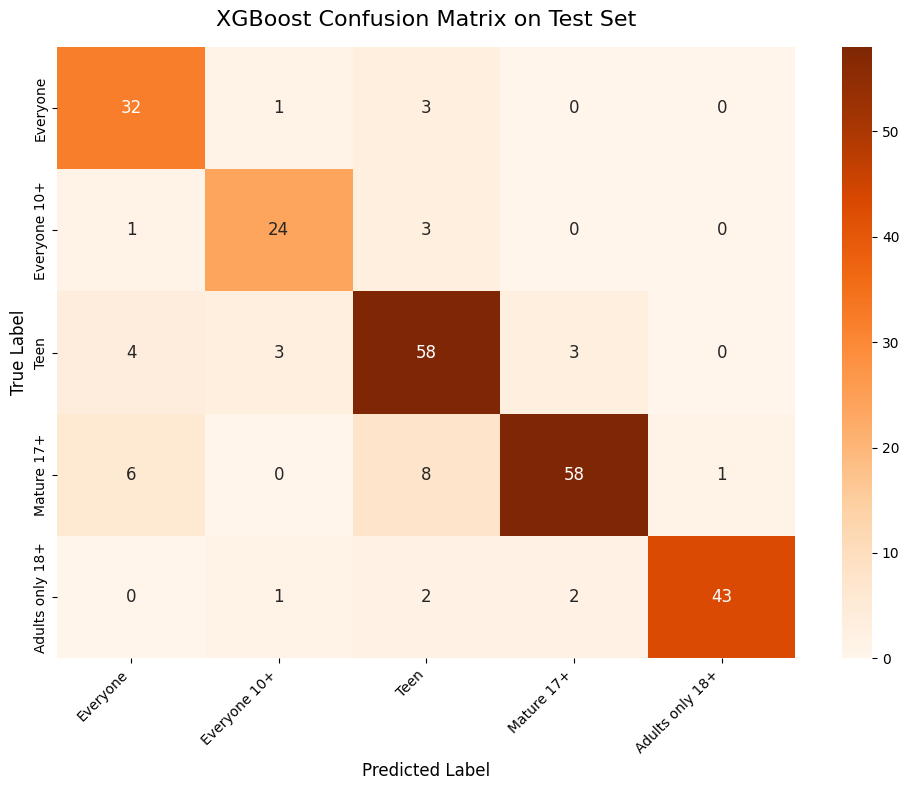

In [11]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 1. 屏蔽冗余警告
warnings.filterwarnings('ignore')

print("开始训练 XGBoost 模型...")

# 2. 初始化 XGBoost 分类器
# 将 early_stopping_rounds 从 fit() 移动到这里
xgb_clf = xgb.XGBClassifier(
    objective='multi:softprob',  
    num_class=len(target_names), 
    n_estimators=500,            
    learning_rate=0.05,          
    max_depth=6,                 
    random_state=42,
    tree_method='hist',          
    verbosity=0,                 
    n_jobs=-1,
    early_stopping_rounds=30
)

# 3. 训练模型
# fit 方法现在变得非常清爽
xgb_clf.fit(
    X_train, y_train,
    sample_weight=sample_weights,  
    eval_set=[(X_val, y_val)],
    verbose=False                  
)

# 4. 测试集预测
y_pred_xgb = xgb_clf.predict(X_test)
y_pred_proba_xgb = xgb_clf.predict_proba(X_test)

# 5. 计算指标
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
auc_score_xgb = roc_auc_score(y_test, y_pred_proba_xgb, multi_class='ovr', average='macro')

print("\n" + "="*50)
print("XGBoost 训练完成！评估结果如下：")
print(f"准确率 (Accuracy)       : {accuracy_xgb:.4f}")
print(f"多分类 AUC (Macro-OVR)  : {auc_score_xgb:.4f}")
print("="*50)

print("\n详细分类报告 (Classification Report):")
print(classification_report(y_test, y_pred_xgb, target_names=target_names))

# 6. 绘制混淆矩阵
plt.figure(figsize=(10, 8))
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=target_names, yticklabels=target_names,
            annot_kws={"size": 12}) 

plt.title('XGBoost Confusion Matrix on Test Set', fontsize=16, pad=15)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right') 
plt.tight_layout()
plt.show()

## 4.使用准确率更高的xgboost进行shap重要性分析

🔍 正在使用【人类可读特征名】重新计算 SHAP 值...

📊 生成可读的全局特征重要性图...


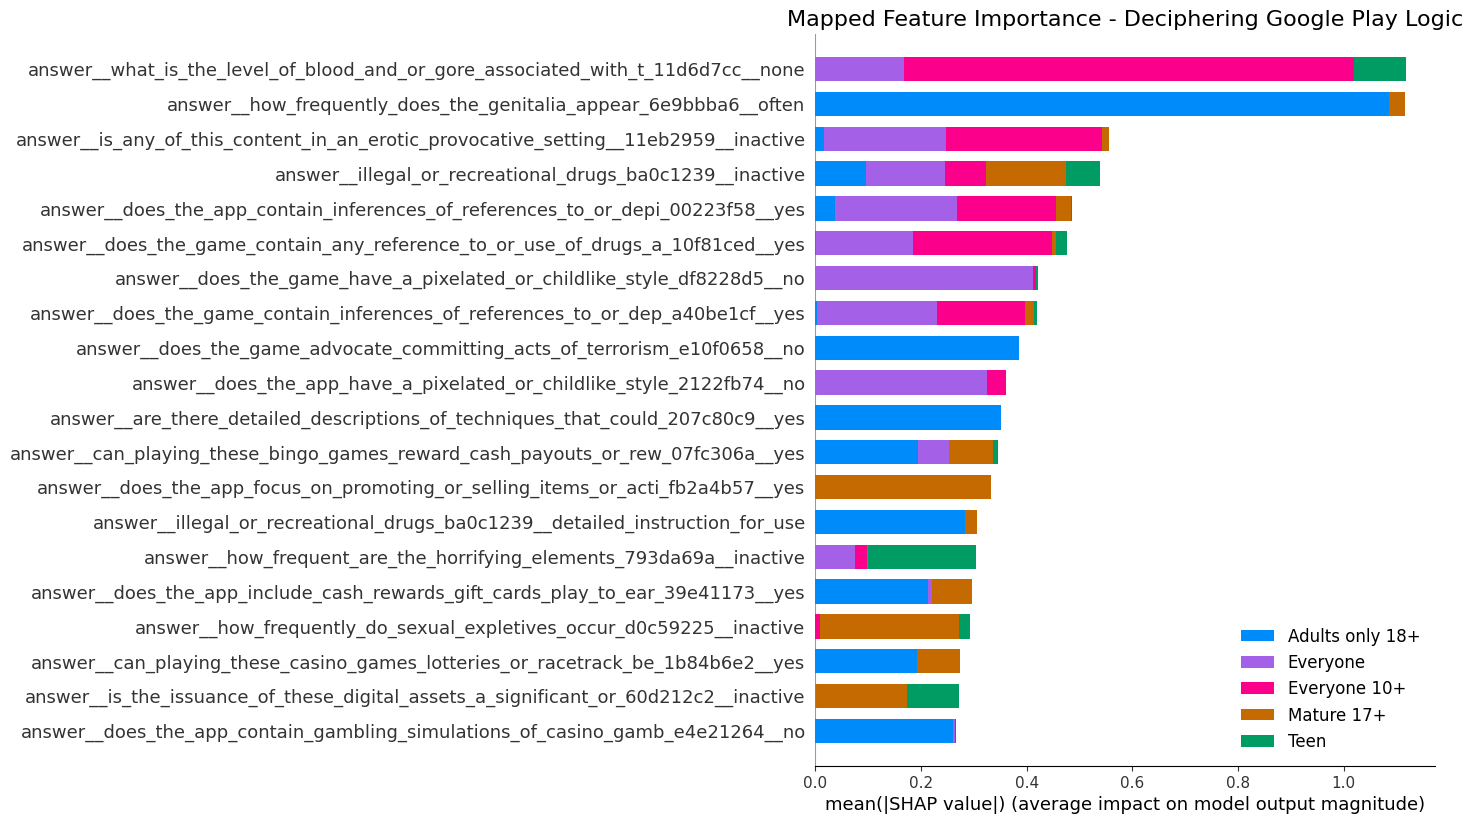


🔞 深度分析：导致 Adults only 18+ 分级的具体问题...


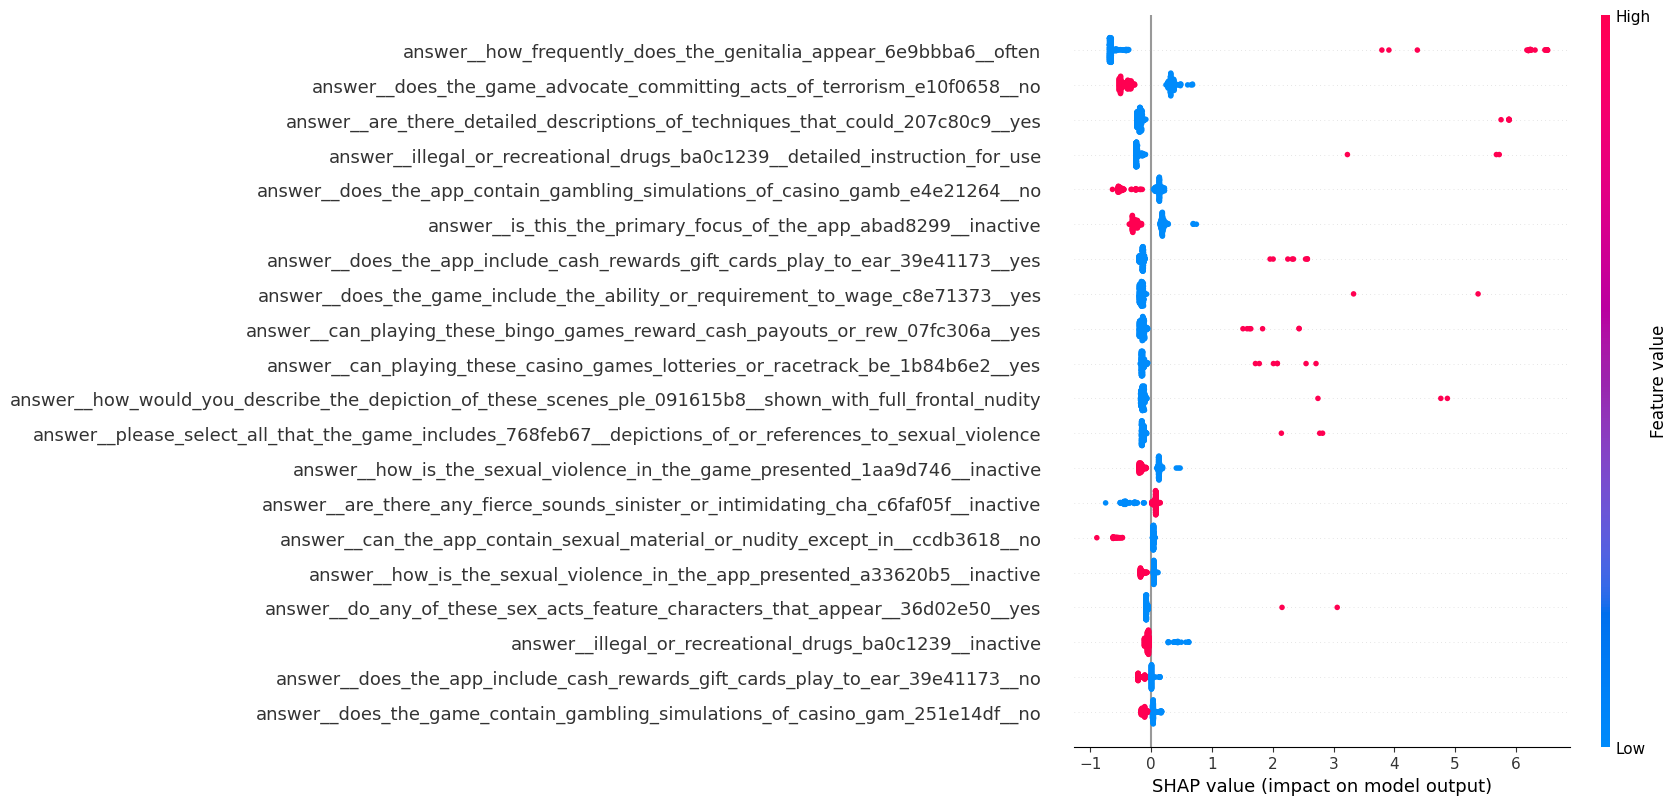


🏆 【最终黑盒破解结果】影响分级的 Top 15 关键问卷问题:
                                                             Questionnaire_Question  SHAP_Value
    answer__what_is_the_level_of_blood_and_or_gore_associated_with_t_11d6d7cc__none    0.223586
                   answer__how_frequently_does_the_genitalia_appear_6e9bbba6__often    0.223271
answer__is_any_of_this_content_in_an_erotic_provocative_setting__11eb2959__inactive    0.111009
                           answer__illegal_or_recreational_drugs_ba0c1239__inactive    0.107840
     answer__does_the_app_contain_inferences_of_references_to_or_depi_00223f58__yes    0.097040
     answer__does_the_game_contain_any_reference_to_or_use_of_drugs_a_10f81ced__yes    0.095459
             answer__does_the_game_have_a_pixelated_or_childlike_style_df8228d5__no    0.084210
     answer__does_the_game_contain_inferences_of_references_to_or_dep_a40be1cf__yes    0.083960
           answer__does_the_game_advocate_committing_acts_of_terrorism_e10f0658__no    0.077008
      

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import shap

# 1. 加载“翻译字典” (Rosetta Stone)
# 这个文件记录了数字 ID 对应的具体问卷问题描述
feature_dict = pd.read_csv('../task4_feature_engineering/output/feature_dictionary.csv')

# 创建一个从 ID 到 描述 的映射字典
# 假设列名为 'feature_index' 和 'description'，请根据实际文件微调
name_map = dict(zip(feature_dict.iloc[:, 0].astype(str), feature_dict.iloc[:, 1]))

# 2. 将原本的数字特征名转换为具体的描述文本
# 如果在字典里找不到，就保留原样
readable_feature_names = [name_map.get(str(f), f"ID_{f}") for f in feature_names]

# 清理非法字符以适配 XGBoost 底层
clean_readable_names = [
    str(f).replace("[", "_").replace("]", "_").replace("<", "_") 
    for f in readable_feature_names
]

print("🔍 正在使用【人类可读特征名】重新计算 SHAP 值...")

# 3. 重新构建 DMatrix (使用翻译后的名称)
dtest_readable = xgb.DMatrix(X_test, feature_names=clean_readable_names)
contribs = xgb_clf.get_booster().predict(dtest_readable, pred_contribs=True)

# 处理多分类数据结构
num_classes = len(target_names)
num_features = len(clean_readable_names)
shap_matrix = contribs.reshape(X_test.shape[0], num_classes, num_features + 1)
shap_values_list = [shap_matrix[:, i, :-1] for i in range(num_classes)]
X_test_dense = X_test.toarray()

# 4. 重新绘制全局特征重要性图 (现在应该是文字了！)
print("\n📊 生成可读的全局特征重要性图...")
plt.figure(figsize=(12, 10))
shap.summary_plot(
    shap_values_list, 
    X_test_dense, 
    feature_names=clean_readable_names, 
    class_names=target_names, 
    show=False
)
plt.title("Mapped Feature Importance - Deciphering Google Play Logic", fontsize=16)
plt.tight_layout()
plt.show()

# 5. 针对 18+ 的深度判罚成因分析
class_idx = target_names.index("Adults only 18+")
print(f"\n🔞 深度分析：导致 {target_names[class_idx]} 分级的具体问题...")
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values_list[class_idx], 
    X_test_dense, 
    feature_names=clean_readable_names, 
    show=False
)
plt.show()

# 6. 输出最终的“黑盒破解清单”
global_importance = np.abs(np.array(shap_values_list)).mean(axis=(0, 1))
final_importance_df = pd.DataFrame({
    'Questionnaire_Question': readable_feature_names,
    'SHAP_Value': global_importance
}).sort_values(by='SHAP_Value', ascending=False)

print("\n🏆 【最终黑盒破解结果】影响分级的 Top 15 关键问卷问题:")
print(final_importance_df.head(15).to_string(index=False))

## 5.Google Play 判定不确定性与灰色地带分析

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 计算预测的“不确定性” (Uncertainty)
# 方法：取最高概率和第二高概率的差值 (Margin)。差值越小，说明模型越纠结
y_proba = xgb_clf.predict_proba(X_test)
probs_sorted = np.sort(y_proba, axis=1)
# 差值：Gap = Top1_Prob - Top2_Prob
margin_gap = probs_sorted[:, -1] - probs_sorted[:, -2]

# 2. 筛选出“最不确定”的前 10 个样本 (灰色地带)
uncertain_indices = np.argsort(margin_gap)[:10]

print("🔍 正在解剖 Google Play 审查机制的【灰色地带】...")
print("-" * 60)

grey_zone_details = []
for idx in uncertain_indices:
    top_two_classes = np.argsort(y_proba[idx])[-2:][::-1]
    grey_zone_details.append({
        "样本索引": idx,
        "第一预测": target_names[top_two_classes[0]],
        "第一概率": f"{y_proba[idx][top_two_classes[0]]:.4f}",
        "第二预测": target_names[top_two_classes[1]],
        "第二概率": f"{y_proba[idx][top_two_classes[1]]:.4f}",
        "不确定度(Gap)": f"{margin_gap[idx]:.4f}"
    })

grey_df = pd.DataFrame(grey_zone_details)
print(grey_df.to_string(index=False))

# 3. 深入分析：为什么这些样本难以判定？
# 提取排名第一的纠结样本，查看其冲突特征
target_sample_idx = uncertain_indices[0]
sample_shap = shap_values_list[np.argmax(y_proba[target_sample_idx])][target_sample_idx]

# 找出该样本中影响力最大的正向和负向特征
sample_data = X_test.toarray()[target_sample_idx]
feature_analysis = []
for i in range(len(sample_shap)):
    if sample_data[i] == 1:
        feature_analysis.append({
            "Feature": name_map.get(str(feature_names[i]), feature_names[i]),
            "Impact": sample_shap[i]
        })

feat_analysis_df = pd.DataFrame(feature_analysis).sort_values(by='Impact', key=abs, ascending=False)

print(f"\n🔬 灰色样本 {target_sample_idx} 的逻辑冲突解剖：")
print(feat_analysis_df.head(10).to_string(index=False))

🔍 正在解剖 Google Play 审查机制的【灰色地带】...
------------------------------------------------------------
 样本索引            第一预测   第一概率            第二预测   第二概率 不确定度(Gap)
  126      Mature 17+ 0.3637        Everyone 0.3627    0.0010
  239      Mature 17+ 0.4430            Teen 0.4419    0.0011
  241      Mature 17+ 0.4430            Teen 0.4419    0.0011
  228            Teen 0.4039 Adults only 18+ 0.3948    0.0091
  207            Teen 0.4292      Mature 17+ 0.4188    0.0103
   23      Mature 17+ 0.3553            Teen 0.3391    0.0162
   50            Teen 0.5036    Everyone 10+ 0.4639    0.0398
  111        Everyone 0.4978      Mature 17+ 0.4547    0.0431
  133 Adults only 18+ 0.4840      Mature 17+ 0.4372    0.0468
    3            Teen 0.4730      Mature 17+ 0.4238    0.0492

🔬 灰色样本 126 的逻辑冲突解剖：
                                                                            Feature    Impact
     answer__does_the_game_contain_any_potentially_offensive_language_3a42be1b__yes  0.282128
              

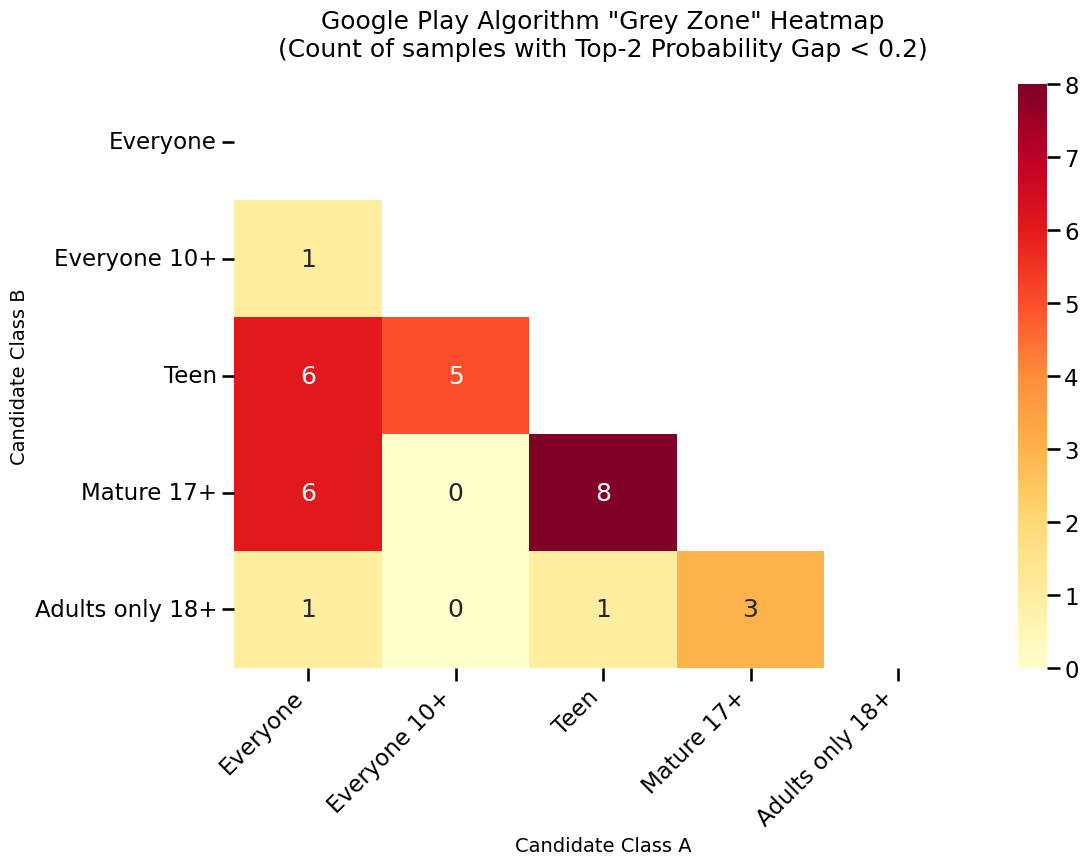

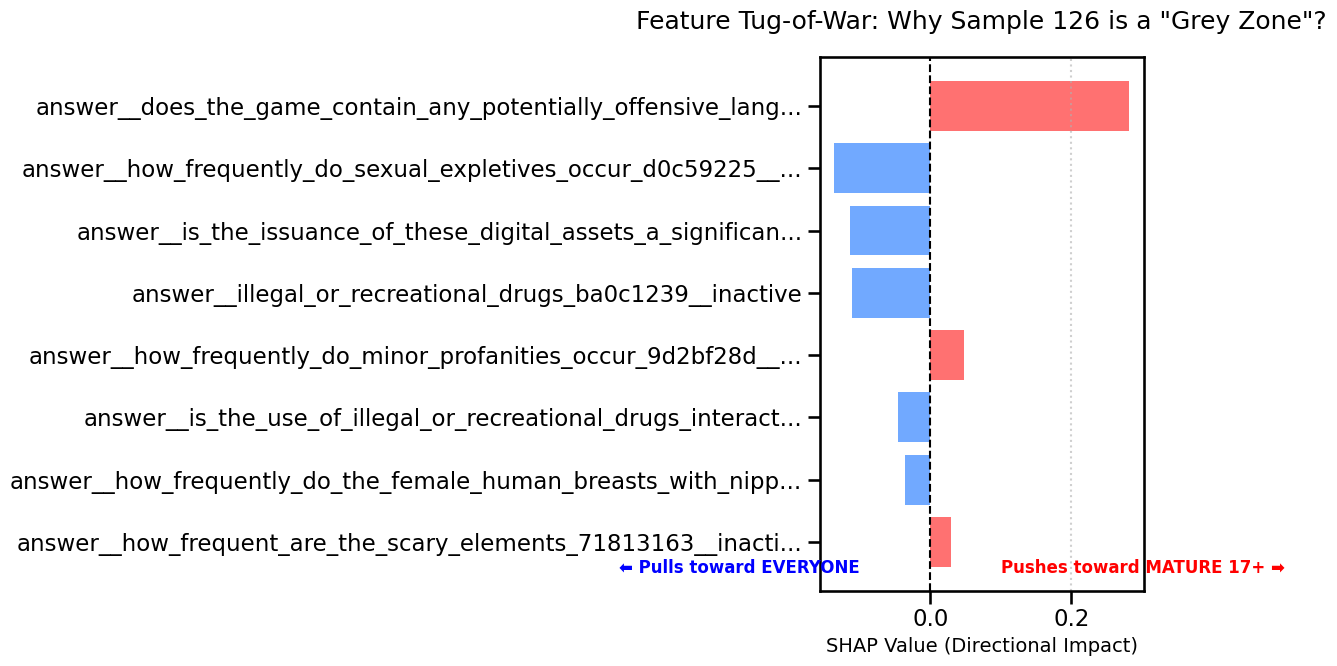

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 设置绘图风格
plt.style.use('seaborn-v0_8-muted')
sns.set_context("talk")

# 1. 构造“灰色地带”混淆矩阵数据 (Uncertainty Heatmap)
# 我们关注那些 Gap < 0.2 的样本，看看它们在哪些类别间摇摆
uncertain_mask = (probs_sorted[:, -1] - probs_sorted[:, -2]) < 0.2
uncertain_indices_all = np.where(uncertain_mask)[0]

# 创建一个 5x5 的矩阵记录 Top 1 和 Top 2 的重合情况
conf_matrix_uncertainty = np.zeros((len(target_names), len(target_names)))

for idx in uncertain_indices_all:
    top_two = np.argsort(y_proba[idx])[-2:]
    conf_matrix_uncertainty[top_two[1], top_two[0]] += 1
    conf_matrix_uncertainty[top_two[0], top_two[1]] += 1 # 对称矩阵

# 绘图 A：不确定性分布热力图
plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(conf_matrix_uncertainty, dtype=bool)) # 只显示下三角
sns.heatmap(conf_matrix_uncertainty, annot=True, fmt='.0f', cmap='YlOrRd',
            xticklabels=target_names, yticklabels=target_names, mask=mask)

plt.title('Google Play Algorithm "Grey Zone" Heatmap\n(Count of samples with Top-2 Probability Gap < 0.2)', 
          fontsize=18, pad=20)
plt.xlabel('Candidate Class A', fontsize=14)
plt.ylabel('Candidate Class B', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------

# 2. 绘制特定样本（126号）的“概率拉锯战” (The Tug-of-War)
sample_id_to_plot = 126
# 选出该样本影响最大的前 8 个特征
top_feat_plot = feat_analysis_df.head(8).copy()

# 为绘图美化特征名称（截断过长的字符串）
top_feat_plot['Short_Feature'] = top_feat_plot['Feature'].apply(lambda x: (x[:60] + '...') if len(x) > 60 else x)

plt.figure(figsize=(12, 7))
colors = ['#ff4d4d' if x > 0 else '#4d94ff' for x in top_feat_plot['Impact']]
bars = plt.barh(top_feat_plot['Short_Feature'], top_feat_plot['Impact'], color=colors, alpha=0.8)

# 添加中心线
plt.axvline(x=0, color='black', linewidth=1.5, linestyle='--')

# 添加文字说明
plt.text(0.1, 7.5, "Pushes toward MATURE 17+ ➡️", color='red', fontweight='bold', fontsize=12)
plt.text(-0.1, 7.5, "⬅️ Pulls toward EVERYONE", color='blue', fontweight='bold', fontsize=12, ha='right')

plt.title(f'Feature Tug-of-War: Why Sample {sample_id_to_plot} is a "Grey Zone"?', fontsize=18, pad=20)
plt.xlabel('SHAP Value (Directional Impact)', fontsize=14)
plt.gca().invert_yaxis() # 重要特征排在上面
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

## 6.问卷冗余度与“过度采集”分析 (Privacy & Efficiency Trade-off)

📉 正在探测决策敏感度曲线（寻找最小特征集）...
维度:  1 | 准确率: 0.3083
维度:  5 | 准确率: 0.4032
维度: 10 | 准确率: 0.4822
维度: 15 | 准确率: 0.5534
维度: 20 | 准确率: 0.5771
维度: 25 | 准确率: 0.6126
维度: 30 | 准确率: 0.6719
维度: 35 | 准确率: 0.6838
维度: 40 | 准确率: 0.6798
维度: 45 | 准确率: 0.6917
维度: 50 | 准确率: 0.6957


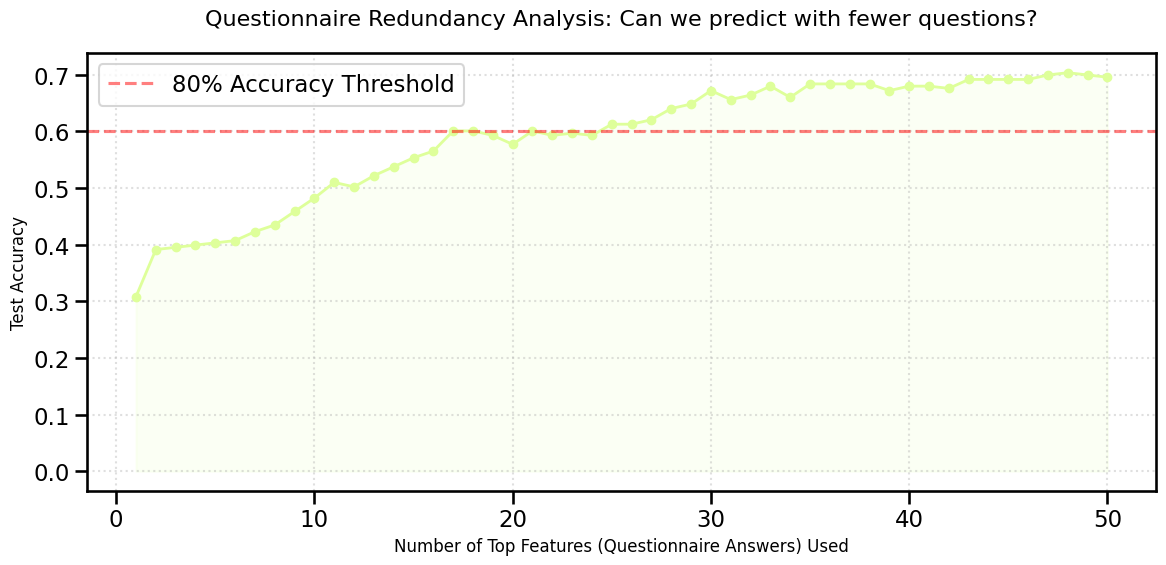

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# 1. 准备特征序列（按之前的 SHAP 重要性排序）
# 我们取前 50 个最重要的特征进行测试
sorted_indices = importance_df.index.tolist()
top_n_to_test = 50

scores = []
feature_counts = list(range(1, top_n_to_test + 1))

print("📉 正在探测决策敏感度曲线（寻找最小特征集）...")

for n in feature_counts:
    # 仅保留排名前 n 的特征
    selected_features = sorted_indices[:n]
    X_train_reduced = X_train[:, selected_features]
    X_test_reduced = X_test[:, selected_features]
    X_val_reduced = X_val[:, selected_features]
    
    # 训练一个轻量级的临时模型（为了速度，参数调低）
    temp_xgb = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        random_state=42,
        tree_method='hist',
        verbosity=0
    )
    temp_xgb.fit(X_train_reduced, y_train, verbose=False)
    
    # 在测试集上评估
    preds = temp_xgb.predict(X_test_reduced)
    acc = accuracy_score(y_test, preds)
    scores.append(acc)
    
    if n % 5 == 0 or n == 1:
        print(f"维度: {n:2d} | 准确率: {acc:.4f}")

# 2. 绘制“冗余度分析”曲线
plt.figure(figsize=(12, 6))
plt.plot(feature_counts, scores, marker='o', linestyle='-', color='#deff9a', linewidth=2, markersize=6)
plt.fill_between(feature_counts, scores, color='#deff9a', alpha=0.1)

# 标注 80% 准确率的临界点
plt.axhline(y=0.6, color='red', linestyle='--', alpha=0.5, label='80% Accuracy Threshold')

plt.title('Questionnaire Redundancy Analysis: Can we predict with fewer questions?', fontsize=16, pad=20)
plt.xlabel('Number of Top Features (Questionnaire Answers) Used', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()